In [ ]:
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import numpy as np

This notebook contains the code used to produce the plots and tables for the automated labelling tool empirical analysis.

## Results: Plots 

In [ ]:

# =============================
# LOAD + STANDARDISE MANUAL
# =============================

manual2 = pd.read_csv('1_Empirical_Analysis_Embeddings/ground_truth/prompt_bias_score_manual_category_gender_stats.csv)')

manual2 = manual2.rename(columns={
    'Category': 'category',
    'low quality image': 'low_quality_image',
    'not sure': 'not_sure'
})

manual2['unlabelled'] = manual2['low_quality_image'] + manual2['not_sure']
manual2['model'] = 'manual baseline'

manual_std = manual2[[
    'category', 'female', 'male', 'unlabelled', 'total',
    'female_pct_clear', 'male_pct_clear', 'prompt_bias_score', 'model'
]].copy()

# =============================
# LOAD + STANDARDISE MODELS
# =============================

model_files = {
    "blip2": "1_Empirical_Analysis_Automated_Labelling_Tools/gender_stats/blip2_gender_stats.csv",
    "clip enhance": "1_Empirical_Analysis_Automated_Labelling_Toolsgender_stats/clip_enhance_gender_stats.csv",
    "clip prob": "1_Empirical_Analysis_Automated_Labelling_Tools/gender_stats/clip_prob_gender_stats.csv",
    "clip": "1_Empirical_Analysis_Automated_Labelling_Tools/gender_stats/clip_gender_stats.csv",
    "clip unc": "1_Empirical_Analysis_Automated_Labelling_Tools/gender_stats/clip_unc_gender_stats.csv",
    "mivolo": "1_Empirical_Analysis_Automated_Labelling_Tools/gender_stats/mivolo_gender_stats.csv",
    "fairface": "1_Empirical_Analysis_Automated_Labelling_Tools/gender_stats/fairface_gender_stats.csv"
}

model_dfs = []

for model_name, file_path in model_files.items():
    df_model = pd.read_csv(file_path)

    df_model = df_model.rename(columns={
        'Category': 'category'
    })

    if 'unlabelled' not in df_model.columns:
        df_model['unlabelled'] = 0

    df_model['model'] = model_name

    # keep only the columns we need
    df_model_std = df_model[[
        'category', 'female', 'male', 'unlabelled', 'total',
        'female_pct_clear', 'male_pct_clear', 'prompt_bias_score', 'model'
    ]].copy()

    model_dfs.append(df_model_std)

# =============================
# COMBINE ALL DATA
# =============================

all_models_df = pd.concat([manual_std] + model_dfs, ignore_index=True)

# clean column names just in case
all_models_df.columns = [c.strip().lower() for c in all_models_df.columns]

# =============================
# SAFELY CONVERT CLEAR PCTS TO PROPORTIONS
# =============================

if all_models_df['female_pct_clear'].dropna().max() > 1 or all_models_df['male_pct_clear'].dropna().max() > 1:
    all_models_df['female_prop_clear'] = all_models_df['female_pct_clear'] / 100.0
    all_models_df['male_prop_clear'] = all_models_df['male_pct_clear'] / 100.0
else:
    all_models_df['female_prop_clear'] = all_models_df['female_pct_clear']
    all_models_df['male_prop_clear'] = all_models_df['male_pct_clear']

# =============================
# STATISTICAL PARITY
# =============================
# female proportion - male proportion among clear labels

all_models_df['statistical_parity'] = (
    all_models_df['female_prop_clear'] - all_models_df['male_prop_clear']
)

all_models_df['abs_statistical_parity'] = all_models_df['statistical_parity'].abs()

# =============================
# MAIN SUMMARY TABLE
# =============================

manual_by_cat = (
    all_models_df[all_models_df['model'] == 'manual baseline'][['category', 'prompt_bias_score']]
    .rename(columns={'prompt_bias_score': 'manual_prompt_bias_score'})
)

manual_by_cat['manual_abs_bias'] = manual_by_cat['manual_prompt_bias_score'].abs()

summary_rows = []

for model_name, df_model in all_models_df.groupby('model'):
    merged = df_model.merge(
        manual_by_cat,
        on='category',
        how='left'
    ).copy()

    merged['abs_bias'] = merged['prompt_bias_score'].abs()
    merged['abs_bias_diff_vs_manual'] = merged['abs_bias'] - merged['manual_abs_bias']

    more_biased = (merged['abs_bias'] > merged['manual_abs_bias']).sum()
    less_biased = (merged['abs_bias'] < merged['manual_abs_bias']).sum()

    summary_rows.append({
        'Model': model_name.title(),
        'Mean Signed Bias': merged['prompt_bias_score'].mean(),
        'Mean Absolute Bias': merged['abs_bias'].mean(),
        'Δ Absolute Bias vs Manual': merged['abs_bias_diff_vs_manual'].mean(),
        'Bias SD Across Categories': merged['abs_bias'].std(),
        '% Categories ↑ Bias': (merged['abs_bias'] > merged['manual_abs_bias']).mean() * 100 if model_name != 'manual baseline' else np.nan,
        '% Categories ↓ Bias': (merged['abs_bias'] < merged['manual_abs_bias']).mean() * 100 if model_name != 'manual baseline' else np.nan,
        'Categories More Biased Than Manual': more_biased if model_name != 'manual baseline' else np.nan,
        'Categories Less Biased Than Manual': less_biased if model_name != 'manual baseline' else np.nan,
        '% Unlabelled Images': merged['unlabelled'].sum() / merged['total'].sum() * 100
    })

summary_df = pd.DataFrame(summary_rows)

# manual first
model_order = [
    'Manual Baseline', 'Blip2', 'Clip Enhance', 'Clip Prob',
    'Clip', 'Clip Unc', 'Mivolo', 'Fairface'
]
summary_df['Model'] = pd.Categorical(summary_df['Model'], categories=model_order, ordered=True)
summary_df = summary_df.sort_values('Model')

print("Main RQ2 summary table:")
display(summary_df.round(4))

# =============================
# STATISTICAL PARITY SUMMARY TABLE
# =============================

stat_parity_summary = (
    all_models_df.groupby('model')
    .agg(
        mean_statistical_parity=('statistical_parity', 'mean'),
        sd_statistical_parity=('statistical_parity', 'std'),
        mean_abs_statistical_parity=('abs_statistical_parity', 'mean')
    )
    .reset_index()
)

stat_parity_summary['Model'] = stat_parity_summary['model'].str.title()
stat_parity_summary = stat_parity_summary.drop(columns='model')

stat_parity_summary['Model'] = pd.Categorical(stat_parity_summary['Model'], categories=model_order, ordered=True)
stat_parity_summary = stat_parity_summary.sort_values('Model')

print("Statistical parity summary table:")
display(stat_parity_summary.round(4))

Main RQ2 summary table:


,Model,Mean Signed Bias,Mean Absolute Bias,Δ Absolute Bias vs Manual,Bias SD Across Categories,% Categories ↑ Bias,% Categories ↓ Bias,Categories More Biased Than Manual,Categories Less Biased Than Manual,% Unlabelled Images
6,Manual Baseline,0.5609,0.7301,0.0000,0.2857,NaN,NaN,NaN,NaN,7.2000
0,Blip2,0.6237,0.7476,0.0175,0.2890,33.0,16.0,33.0,16.0,2.0000
2,Clip Enhance,0.5556,0.7208,-0.0094,0.2976,20.0,18.0,20.0,18.0,7.2000
3,Clip Prob,0.4383,0.6990,-0.0312,0.4146,44.0,29.0,44.0,29.0,84.2500
1,Clip,0.5350,0.7010,-0.0291,0.2769,29.0,36.0,29.0,36.0,0.0000
4,Clip Unc,0.6936,0.7643,0.0342,0.2949,42.0,28.0,42.0,28.0,34.6500
7,Mivolo,0.5878,0.7267,-0.0035,0.3090,26.0,22.0,26.0,22.0,5.0000
5,Fairface,0.5696,0.7241,-0.0061,0.2757,24.0,21.0,24.0,21.0,5.5528


Statistical parity summary table:


,mean_statistical_parity,sd_statistical_parity,mean_abs_statistical_parity,Model
6,-0.5609,0.5499,0.7301,Manual Baseline
0,-0.6237,0.5051,0.7476,Blip2
2,-0.5556,0.5491,0.7208,Clip Enhance
3,-0.5218,0.7198,0.8321,Clip Prob
1,-0.5350,0.5328,0.7010,Clip
4,-0.6936,0.4371,0.7643,Clip Unc
7,-0.5878,0.5290,0.7267,Mivolo
5,-0.5696,0.5271,0.7241,Fairface


In [ ]:

# merge manual baseline
manual_by_cat = (
    all_models_df[all_models_df['model'] == 'manual baseline'][['category', 'prompt_bias_score']]
    .rename(columns={'prompt_bias_score': 'manual_bias'})
)

manual_by_cat['manual_abs_bias'] = manual_by_cat['manual_bias'].abs()

plot_df = all_models_df.merge(manual_by_cat, on='category', how='left').copy()

plot_df['abs_bias'] = plot_df['prompt_bias_score'].abs()
plot_df['abs_bias_diff'] = plot_df['abs_bias'] - plot_df['manual_abs_bias']

epsilon = 1e-6  # avoid division by zero

plot_df['pct_bias_diff'] = (
    (plot_df['prompt_bias_score'] - plot_df['manual_bias']) /
    (plot_df['manual_bias'].replace(0, np.nan))
) * 100
plot_df_filtered = plot_df[np.abs(plot_df['manual_bias']) > 0.05]

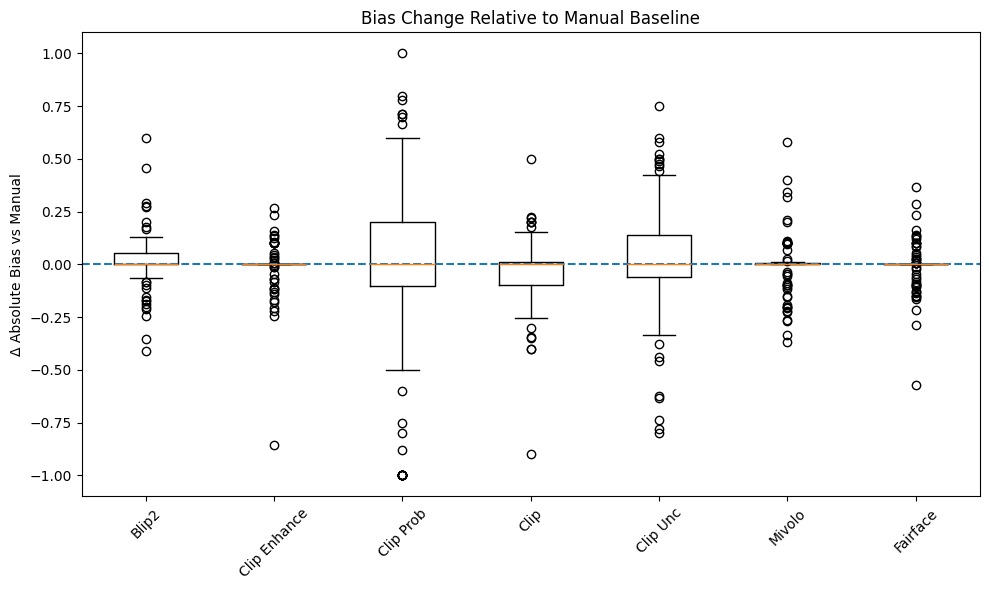

In [15]:
plt.figure(figsize=(10,6))

data = []
labels = []

for model in plot_df['model'].unique():
    if model == 'manual baseline':
        continue

    vals = plot_df[plot_df['model'] == model]['abs_bias_diff'].dropna()
    data.append(vals)
    labels.append(model.title())

plt.boxplot(data)
plt.axhline(0, linestyle='--')  # baseline

plt.xticks(range(1, len(labels)+1), labels, rotation=45)
plt.ylabel('Δ Absolute Bias vs Manual')
plt.title('Bias Change Relative to Manual Baseline')

plt.tight_layout()
plt.show()

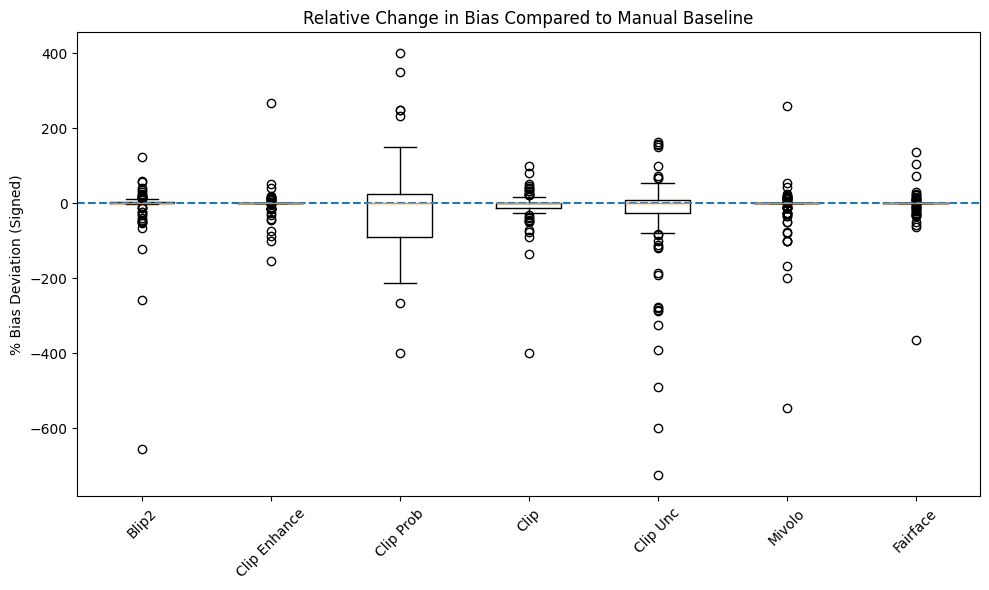

In [21]:
plt.figure(figsize=(10,6))

data = []
labels = []

for model in plot_df_filtered['model'].unique():
    if model == 'manual baseline':
        continue

    vals = plot_df_filtered[plot_df_filtered['model'] == model]['pct_bias_diff'].dropna()
    data.append(vals)
    labels.append(model.title())

plt.boxplot(data)
plt.axhline(0, linestyle='--')

plt.xticks(range(1, len(labels)+1), labels, rotation=45)
plt.ylabel('% Bias Deviation (Signed)')
plt.title('Relative Change in Bias Compared to Manual Baseline')

plt.tight_layout()
plt.savefig("relative_change_bias_vs_manual.pdf", bbox_inches="tight")
plt.show()

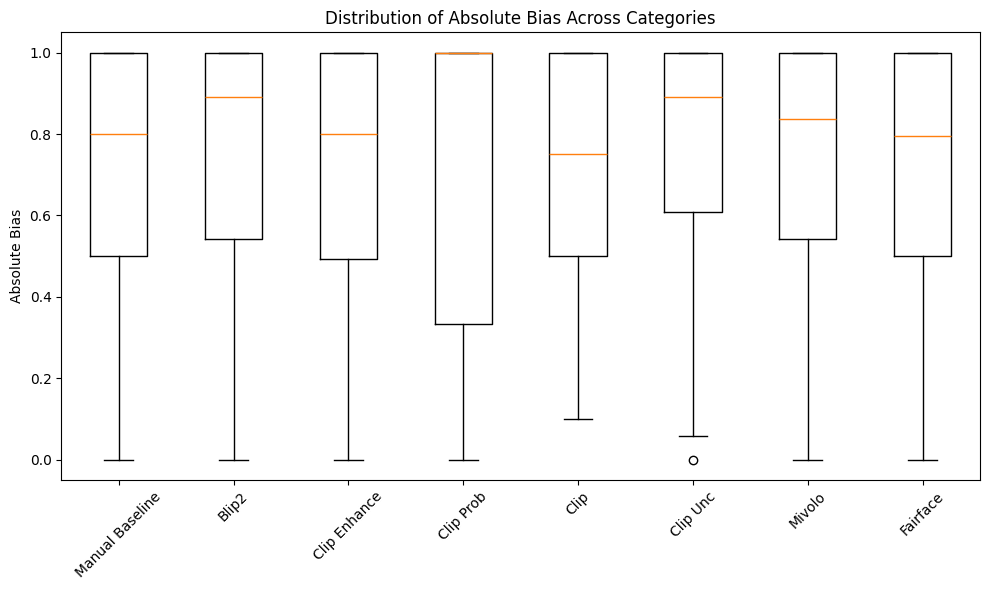

In [17]:
plt.figure(figsize=(10,6))

data = []
labels = []

for model in plot_df['model'].unique():
    vals = plot_df[plot_df['model'] == model]['abs_bias'].dropna()
    data.append(vals)
    labels.append(model.title())

plt.boxplot(data)

plt.xticks(range(1, len(labels)+1), labels, rotation=45)
plt.ylabel('Absolute Bias')
plt.title('Distribution of Absolute Bias Across Categories')

plt.tight_layout()
plt.show()

## Table Summaries

In [ ]:
# Prompt bias score difference by category
manual2 = pd.read_csv('1_Empirical_Analysis_Embeddings/ground_truth/prompt_bias_score_manual_category_gender_stats.csv)')
manual2 = manual2.rename(columns={'Category': 'category'})
model_files = {
    "blip2": "1_Empirical_Analysis_Automated_Labelling_Tools/gender_stats/blip2_gender_stats.csv",
    "clip enhance": "1_Empirical_Analysis_Automated_Labelling_Toolsgender_stats/clip_enhance_gender_stats.csv",
    "clip prob": "1_Empirical_Analysis_Automated_Labelling_Tools/gender_stats/clip_prob_gender_stats.csv",
    "clip": "1_Empirical_Analysis_Automated_Labelling_Tools/gender_stats/clip_gender_stats.csv",
    "clip unc": "1_Empirical_Analysis_Automated_Labelling_Tools/gender_stats/clip_unc_gender_stats.csv",
    "mivolo": "1_Empirical_Analysis_Automated_Labelling_Tools/gender_stats/mivolo_gender_stats.csv",
    "fairface": "1_Empirical_Analysis_Automated_Labelling_Tools/gender_stats/fairface_gender_stats.csv"
}


In [ ]:
# Prompt bias score differences by category

# Merge all model files with manual2
results = manual2[['category', 'prompt_bias_score', 'total']].rename(columns={'prompt_bias_score': 'manual_prompt_bias_score', 'total': 'manual_total'})

for name, path in model_files.items():
    model = pd.read_csv(path)
    results = results.merge(
        model[['category', 'prompt_bias_score', 'clear_total']],
        on='category',
        how='left',
        suffixes=('', f'_{name}')
    )
    # Calculate difference normalised by image count
    results[f'{name}_bias_score_diff_normalised'] = (
        (results[f'prompt_bias_score'] - results['manual_prompt_bias_score']) /
        (results[f'clear_total'] + results['manual_total'])
    )

    results[f'{name}_bias_score_diff_real'] = (
        (results[f'prompt_bias_score'] - results['manual_prompt_bias_score'])
    )

    results[f'{name}_bias_score_pct_diff'] = (
        (results[f'prompt_bias_score'] - results['manual_prompt_bias_score']) / results['manual_prompt_bias_score']
    ) * 100

    # Rename for next iteration
    results = results.rename(columns={'prompt_bias_score': f'prompt_bias_score_{name}', 'clear_total': f'clear_total_{name}'})

# Save or display results
results.to_csv('2prompt_bias_score_differences_by_category.csv', index=False)
results.head()

diff_cols = [col for col in results.columns if col.endswith('_bias_score_diff_normalised')]
results[['category'] + diff_cols].to_csv('normalised_bias_score_diffs_only.csv', index=False)


diff_cols2 = [col for col in results.columns if col.endswith('_bias_score_pct_diff')]
results[['category'] + diff_cols2].to_csv('bias_score_pct_diffs_only.csv', index=False)

diff_cols2 = [col for col in results.columns if col.endswith('_bias_score_diff_real')]
results[['category'] + diff_cols2].to_csv('real_bias_score_diffs_only.csv', index=False)


In [ ]:
# Table of number of images models are able to label 
manual2['manual_low_quality'] = manual2['total'] - manual2['clear_total']
variation_table = manual2[['category', 'manual_low_quality']].copy()

for name, path in model_files.items():
    model = pd.read_csv(path)
    model = model.rename(columns={'Category': 'category'}) 
    model['model_low_quality'] = model['total'] - model['clear_total']
    merged = manual2[['category', 'manual_low_quality']].merge(
        model[['category', 'model_low_quality']], on='category', how='left'
    )
    # Percentage variation
    variation_table[f'{name}_low_quality_pct_variation'] = (
        (merged['model_low_quality'] - merged['manual_low_quality']) / merged['manual_low_quality']
    ) * 100

variation_table = variation_table.replace([float('inf'), float('-inf')], pd.NA)
variation_table = variation_table.fillna("N/A")

variation_table.to_csv('low_quality_pct_variation_by_category.csv', index=False)
variation_table.head()

In [ ]:
# Unlabelled images by category
manual2['manual_low_quality'] = manual2['total'] - manual2['clear_total']
unlabeled_table = manual2[['category', 'manual_low_quality']].copy()

for name, path in model_files.items():
    model = pd.read_csv(path)
    model = model.rename(columns={'Category': 'category'})  
    model['model_low_quality'] = model['total'] - model['clear_total']
    merged = manual2[['category']].merge(
        model[['category', 'model_low_quality']], on='category', how='left'
    )
    unlabeled_table[f'{name}_low_quality'] = merged['model_low_quality']

unlabeled_table.to_csv('unlabeled_images_by_category.csv', index=False)
unlabeled_table.head()